In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [72]:
def load_data():
    path = os.path.join("data", "lego_normalized_features.csv")
    df = pd.read_csv(path)
    window =  sorted(list(df["window_index"].unique()))[-2]
    df = df[df["window_index"] == window]
    independent_feature_cols = ["num_parts", "unique_part_count", "minifig_count", 
                "spare_part_ratio", "h_cat", "h_col", 
                "prop_technic", "prop_printed", "prop_transparent", 
                "rare_part_ratio", "minifig_to_part_ratio", "has_minifigs"]
    X = df[independent_feature_cols].values
    return X

In [35]:
def compute_metrics(X, k_range):
    inertias = []
    silhouette_scores = []

    for k in k_range:
        kmeans = KMeans(n_clusters = k, init = "k-means++", n_init = 10, random_state = 42)
        labels = kmeans.fit_predict(X)

        inertias.append(kmeans.inertia_)

        score = silhouette_score(X, labels)
        silhouette_scores.append(score)

        print(f"k={k:2d} | Inertia={kmeans.inertia_:10.2f} | Silhouette={score:.4f}")

    return inertias, silhouette_scores

In [36]:
def find_elbow_k(k_range, inertias):
    """
    Estimate the elbow point using the 'knee' heuristic:
    point with maximum distance from the line connecting
    the first and last points of the inertia curve.
    """
    k_range = np.array(list(k_range))
    inertias = np.array(inertias)
 
    # Normalize
    x = (k_range - k_range.min()) / (k_range.max() - k_range.min())
    y = (inertias - inertias.min()) / (inertias.max() - inertias.min())
 
    # Line from first to last point
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
 
    distances = []
    for xi, yi in zip(x, y):
        point = np.array([xi, yi])
        proj_len = np.dot(point - p1, line_vec_norm)
        proj_point = p1 + proj_len * line_vec_norm
        distances.append(np.linalg.norm(point - proj_point))
 
    elbow_idx = int(np.argmax(distances))
    return k_range[elbow_idx]
 
 
def find_best_silhouette_k(k_range, silhouette_scores):
    k_range = list(k_range)
    best_idx = int(np.argmax(silhouette_scores))
    return k_range[best_idx]

In [37]:
def plot_elbow(k_range, inertias, elbow_k, save_path):
    plt.figure(figsize=(8, 5))
    plt.plot(list(k_range), inertias, marker="o", linestyle="-", color="steelblue")
    plt.axvline(x=elbow_k, color="red", linestyle="--", label=f"Elbow at k={elbow_k}")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
    plt.title("Elbow Method for Optimal k")
    plt.xticks(list(k_range))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
 
 
def plot_silhouette(k_range, silhouette_scores, best_k, save_path):
    plt.figure(figsize=(8, 5))
    plt.plot(list(k_range), silhouette_scores, marker="o", linestyle="-", color="seagreen")
    plt.axvline(x=best_k, color="red", linestyle="--", label=f"Best k={best_k}")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.title("Silhouette Score for Optimal k")
    plt.xticks(list(k_range))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

In [57]:
def plot_combined(k_range, inertias, silhouette_scores, elbow_k, best_k, save_path):
    fig, ax1 = plt.subplots(figsize=(9, 5))

    color1 = "steelblue"
    ax1.set_xlabel("Number of Clusters (k)")
    ax1.set_ylabel("Inertia", color=color1)
    ax1.plot(list(k_range), inertias, marker="o", color=color1, label="Inertia")
    ax1.tick_params(axis="y", labelcolor=color1)
    ax1.set_xticks(list(k_range))

    vline1 = ax1.axvline(x=elbow_k, color="lightblue", linestyle="--", label=f"Elbow at k={elbow_k}")

    ax2 = ax1.twinx()
    color2 = "seagreen"
    ax2.set_ylabel("Silhouette Score", color=color2)
    ax2.plot(list(k_range), silhouette_scores, marker="s", color=color2, label="Silhouette Score")
    ax2.tick_params(axis="y", labelcolor=color2)

    vline2 = ax2.axvline(x=best_k, color="lightgreen", linestyle="--", label=f"Best k={best_k}")

    plt.title("Elbow Method vs. Silhouette Score")

    ax1.legend(handles=[vline1, vline2], loc="best")

    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

In [60]:
def plot_cluster_sizes(labels, k, save_path):
    unique, counts = np.unique(labels, return_counts=True)

    plt.figure(figsize=(7, 5))
    bars = plt.bar(unique, counts, color="steelblue", edgecolor="black")

    # Annotate each bar with its count
    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            str(count),
            ha="center",
            va="bottom",
        )

    plt.xlabel("Cluster")
    plt.ylabel("Number of Points")
    plt.title(f"Cluster Size Distribution (k={k})")
    plt.xticks(unique)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

k= 3 | Inertia=   3597.78 | Silhouette=0.2054
k= 4 | Inertia=   3190.54 | Silhouette=0.1824
k= 5 | Inertia=   2819.57 | Silhouette=0.2168
k= 6 | Inertia=   2550.32 | Silhouette=0.2261
k= 7 | Inertia=   2289.10 | Silhouette=0.2313
k= 8 | Inertia=   2084.63 | Silhouette=0.2093
k= 9 | Inertia=   1954.58 | Silhouette=0.1971
k=10 | Inertia=   1792.92 | Silhouette=0.2204
k=11 | Inertia=   1662.82 | Silhouette=0.2162
k=12 | Inertia=   1556.52 | Silhouette=0.2188
k=13 | Inertia=   1484.03 | Silhouette=0.2161
k=14 | Inertia=   1418.45 | Silhouette=0.2139
k=15 | Inertia=   1369.78 | Silhouette=0.2195


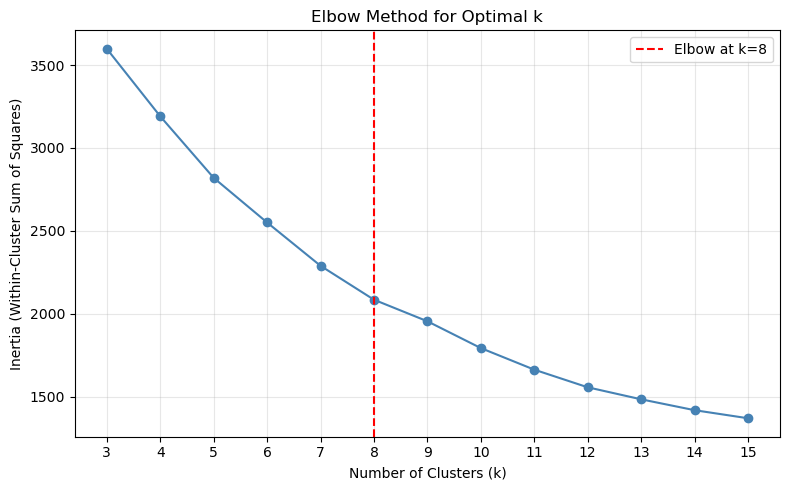

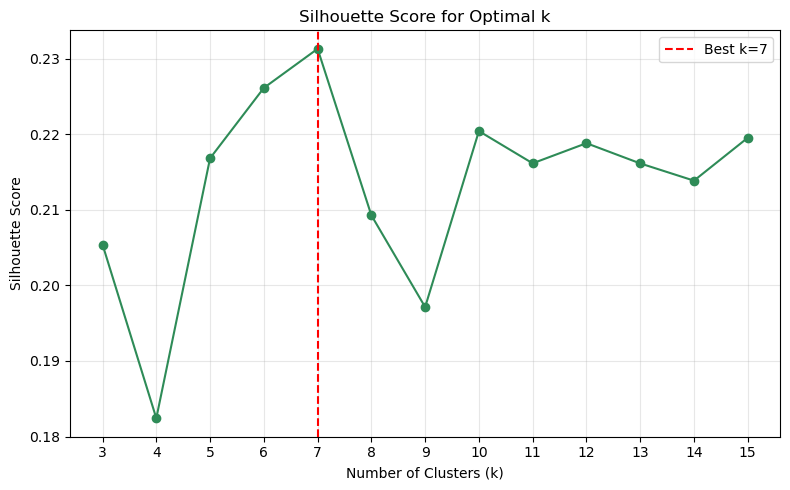

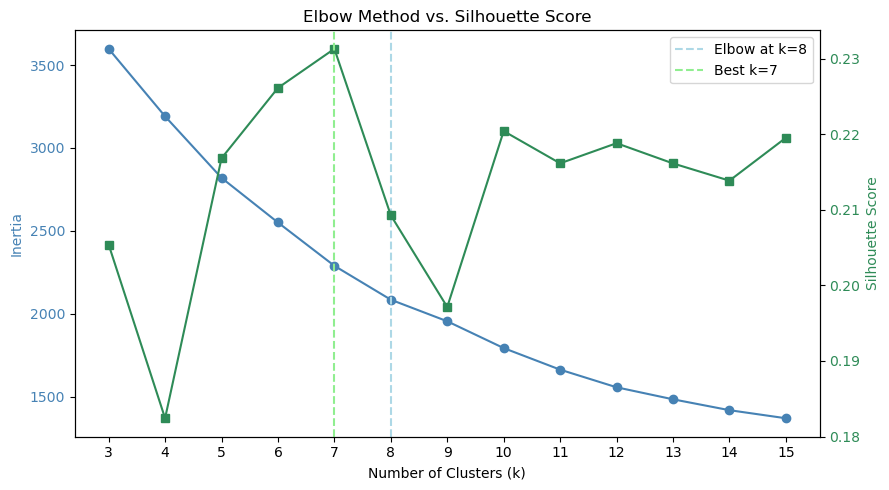

[[14.88310919  5.9086554  14.33601414 -0.32871064  0.65948247 -0.15668078
  -0.31818092 -0.40053715 -0.28923561 -0.4280663  -0.19484065  1.        ]]


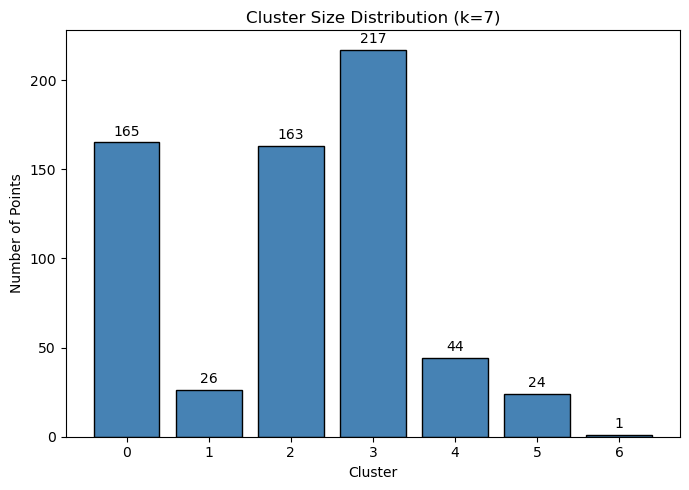

[[ 0.71406177  0.33317598 -0.60447403 ... -0.26336028 -0.28846112
   0.        ]
 [-0.0985798  -0.10190478 -0.60447403 ... -0.19509614 -0.28846112
   0.        ]
 [-0.01132776 -0.18247529 -0.60447403 ...  0.02197666 -0.28846112
   0.        ]
 ...
 [-0.52286425 -0.87538169 -0.23096182 ... -0.48207373  0.65380762
   1.        ]
 [-0.53312919 -0.8914958   0.14255038 ... -0.48207373  3.48061384
   1.        ]
 [-0.52799672 -0.82703939 -0.23096182 ... -0.48207373  0.86320068
   1.        ]]


In [77]:
def main():
    X = load_data()

    k_range = range(3, 16)

    inertias, silhouette_scores = compute_metrics(X, k_range)

    elbow_k = find_elbow_k(k_range, inertias)
    best_silhouette_k = find_best_silhouette_k(k_range, silhouette_scores)

    elbow_graph = os.path.join("outputs", "elbow_plt.png")
    silhouette_graph = os.path.join("outputs", "silhouette_plt.png")

    plot_elbow(k_range, inertias, elbow_k, elbow_graph)
    plot_silhouette(k_range, silhouette_scores, best_silhouette_k, silhouette_graph)

    combined_graph = os.path.join("outputs", "combined_plt.png")
    plot_combined(k_range, inertias, silhouette_scores, elbow_k, best_silhouette_k, combined_graph)

    final_kmeans = KMeans(n_clusters=best_silhouette_k, init="k-means++", n_init=10, random_state=42)
    final_labels = final_kmeans.fit_predict(X)

    print(X[final_labels == 6])
 
    cluster_sizes = os.path.join("outputs", "cluster_sizes.png")
    plot_cluster_sizes(final_labels, best_silhouette_k, cluster_sizes)

    print(X)
    

main()